# Lab 1 – Neural Networks and Data Analysis  
### Statement of Originality and Contributions  

This notebook was developed as part of **Lab 1 – Introduction to Machine Learning and Data Analysis**.  
All code, analyses, and visualizations were created independently for educational purposes.  
External resources were limited to official documentation, course materials and output of the ai model (Sonnet 4.5) for code debugging and formulation. All responisbillity for incorrect output lies on us.

**Contributors:**  
- Powered by Yannick Kandulski and Divine Mekoagne Tietse
- All authors contributed equally.

**Objective:**  
This project introduces basics of a machine learning pipeline — from data exploration and preprocessing to model design, training, and evaluation.  
The dataset used is the *Wine Quality Dataset* from the UCI Machine Learning Repository.

**Notebook Execution**:
- Google Colab
---

### Environment Specification

The notebook was developed and tested using the following environment:

| Package | Version |
|----------|----------|
| Python | 3.12.12 |
| NumPy | (2.0.2) |
| Pandas | (2.2.2) |
| Matplotlib | (3.10.0) |
| Seaborn | (0.13.2) |
| Scikit-learn | (1.6.1) |
| PyTorch | (2.8.0+cu126) |

The environment setup ensures reproducibility and consistency across runs.


## References
1. Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.
2. https://www.lyzr.ai/glossaries/learning-rate/

1. Setup and Environment

### 1.1 Imports of required packages

In [1]:
#Packages import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets
import sys
import torch
import torch.nn as nn
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

### 1.2 Enviroment specification for Analysis, Evaluation and Training:

In [2]:
print('torch version:', torch.__version__)
print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('Seaborn version:', sns.__version__)
print('Scikit-learn version:', sklearn.__version__)
print('PyTorch version:', torch.__version__)

torch version: 2.9.0+cu126
Python version: 3.12.12
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
PyTorch version: 2.9.0+cu126


# 2. Data definition: (Load Data)

### 2.1 Loading the Dataset and understanding the Shape of the data

#### Relevant Information about the Dataset:
- "The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009]." [*1]

 - "The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods." [*1]
 - "quality (score between 0 and 10)" [*1]

- fixed acidity - g/dm³
- volatile acidity - g/dm³
- citric acid - g/dm³
- residual sugar - g/dm³
- chlorides - g/dm³
- free sulfur dioxide - mg/dm³
- total sulfur dioxide - mg/dm³
- density - g/cm³
- pH - pH scale: 0-14
- sulphates - g/dm³
- alcohol - % by volume
- quality - score 0-10 scale

In [3]:
#Loading of the dataset as a dataframe
wine = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
    sep=";"
)
X = wine.drop('quality', axis=1)  # Features only


# 3. Data Exploration

### 3.1 Dataset Shape and Statistics

In [4]:
print(wine.describe())
y = wine['quality'] # target only

print("\n===================Data Types=======================")
print("Feature data types:")
print(X.dtypes)
print(f"\nTarget variable type: {y.dtype}")
print("\nAll features are continuous numerical variables (float64).")
print("The target 'quality' is an integer score between 0-10 in this dataset.")
print("\n======================First Rows==============================")

display(wine.head())#Print of a brief description of the dataset
print("\n======================Shape==============================")
print(f"shape(wine): {wine.shape}")

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



======================Shape==============================
shape(wine): (1599, 12)


Meaning there are:
- 1599 Samples
- 12 Features

### 3.2 Histogram

<Figure size 640x480 with 0 Axes>

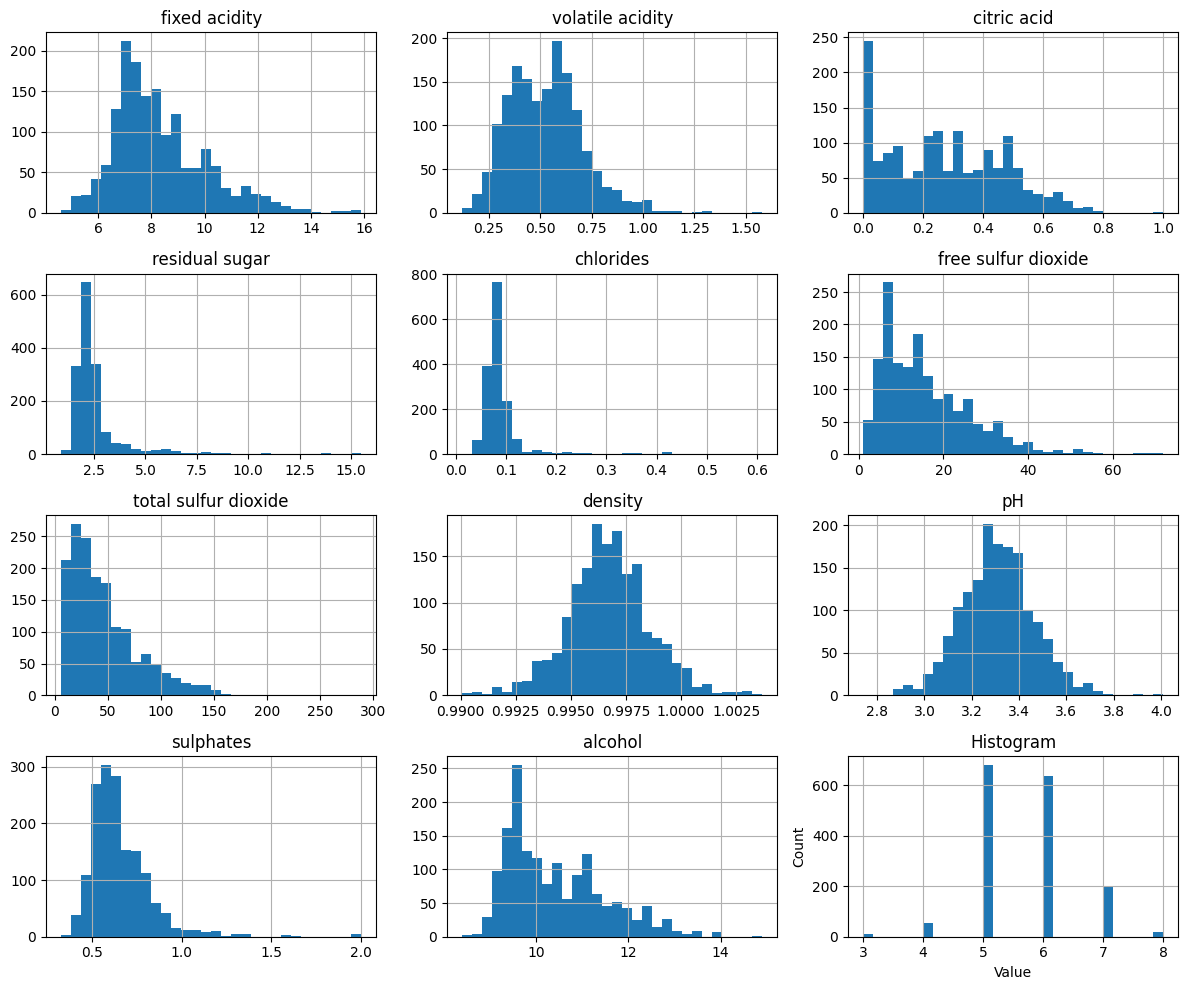

In [5]:
df_long = wine.melt(var_name="Feature", value_name="Value")
plt.figure()
wine.hist(figsize=(12, 10), bins=30)
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Oberservations:
- Residual sugar and chlorides: Heavily right skewed with outliers, most wines are dry with low chloride content
- Citric acid: Somewhat flat distribution with spike near zero,some wines may have none added

- Outliers and different scales present in the features, scaling will help

### 3.3 Violin Plot

- This violin plot once again shows us that outlier treatment or scaling is necessary

variable means: fixed acidity            8.319637
volatile acidity         0.527821
citric acid              0.270976
residual sugar           2.538806
chlorides                0.087467
free sulfur dioxide     15.874922
total sulfur dioxide    46.467792
density                  0.996747
pH                       3.311113
sulphates                0.658149
alcohol                 10.422983
dtype: float64


<Figure size 640x480 with 0 Axes>

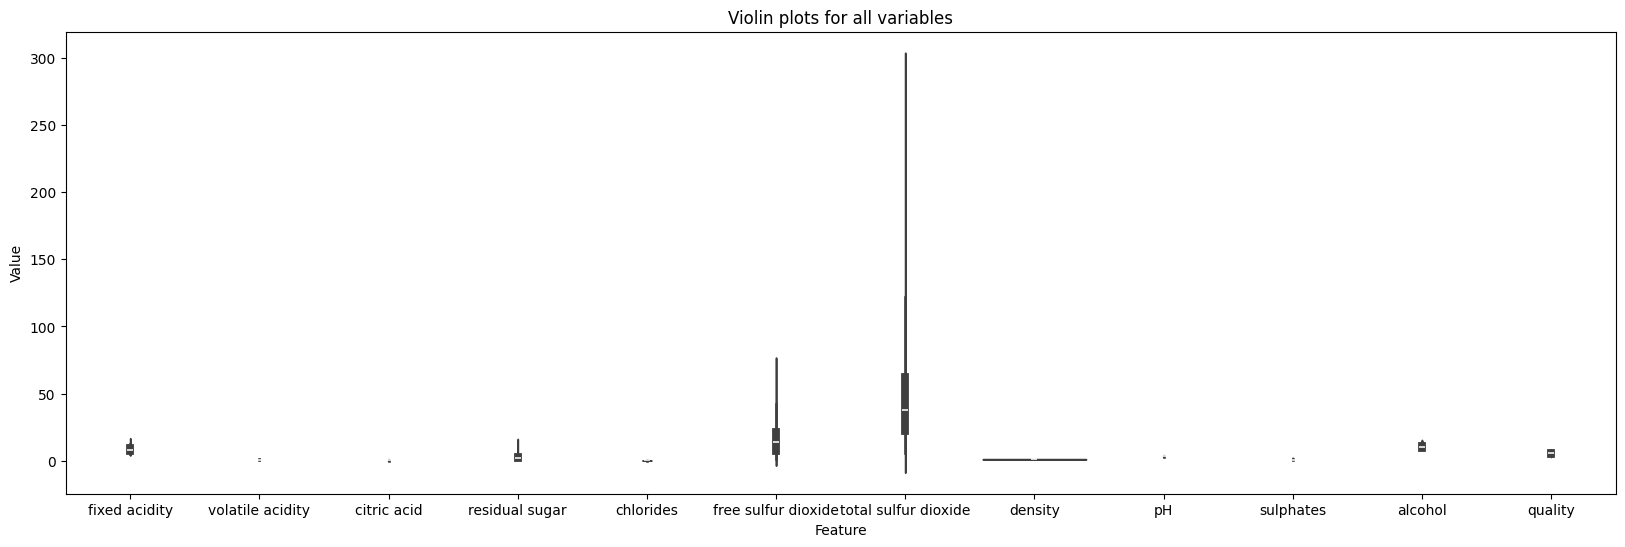

In [6]:
print(f"variable means: {np.mean(X, axis=0)}")
plt.figure()
plt.figure(figsize=(20, 6))
sns.violinplot(x="Feature", y="Value", data=df_long)
#plt.xticks(rotation=45, ha='right')
plt.title("Violin plots for all variables")
# plt.subplots(ncols=2, nrows=2)
plt.show()

### 3.4 Check Data for missinng Values

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64


<Figure size 640x480 with 0 Axes>

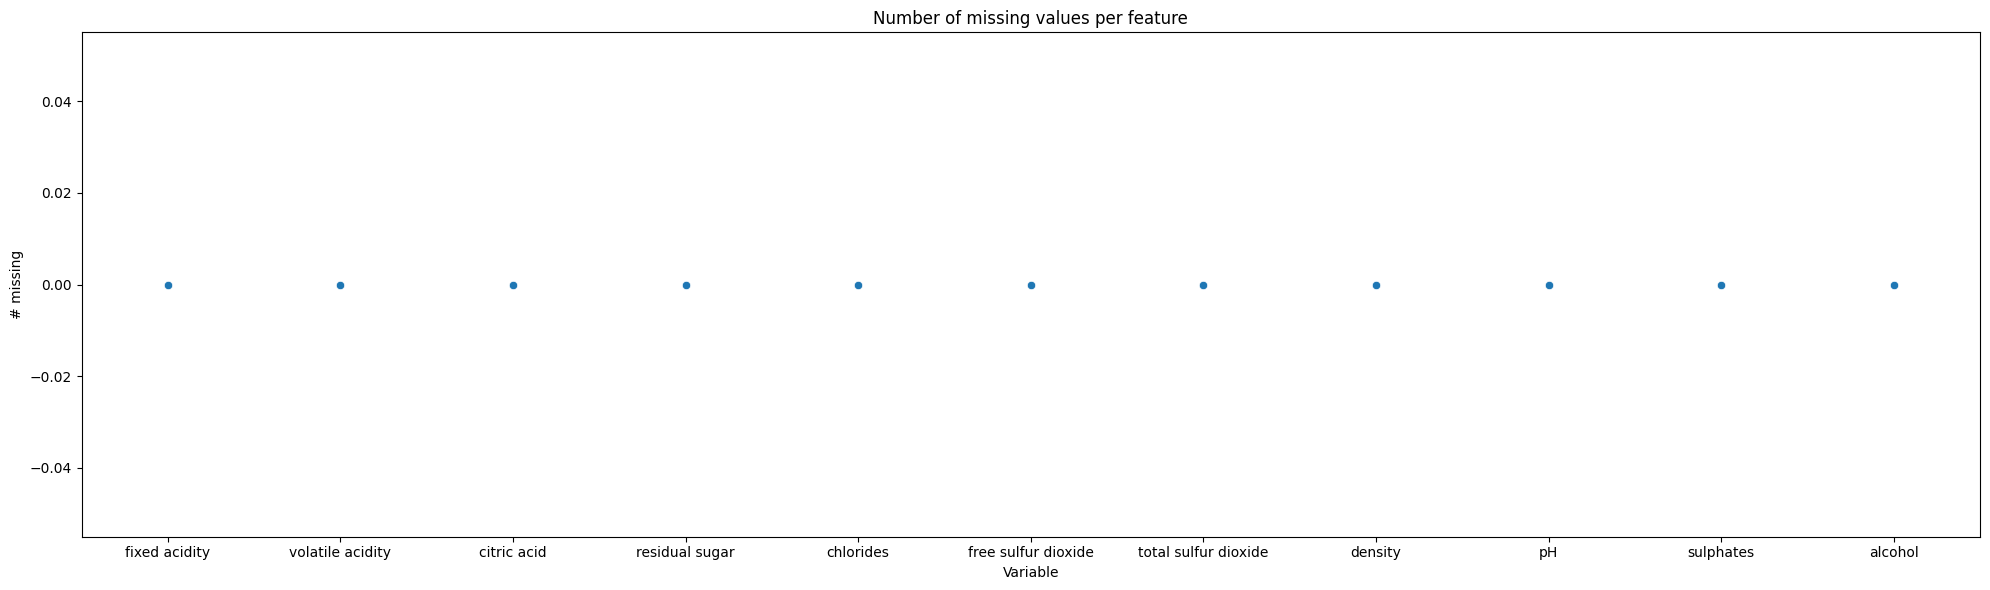

In [7]:
na_counts = X.isna().sum() # pandas
#na_counts = np.isnan(X).sum(axis=0) # numpy
print("Missing values:\n", na_counts)
plt.figure()
plt.figure(figsize=(20, 6))
sns.scatterplot(x=na_counts.index, y=na_counts.values)
plt.title("Number of missing values per feature")
plt.xlabel("Variable")
plt.ylabel("# missing")

plt.tight_layout()
plt.show()

### 3.5 Heatmap (not usefull)

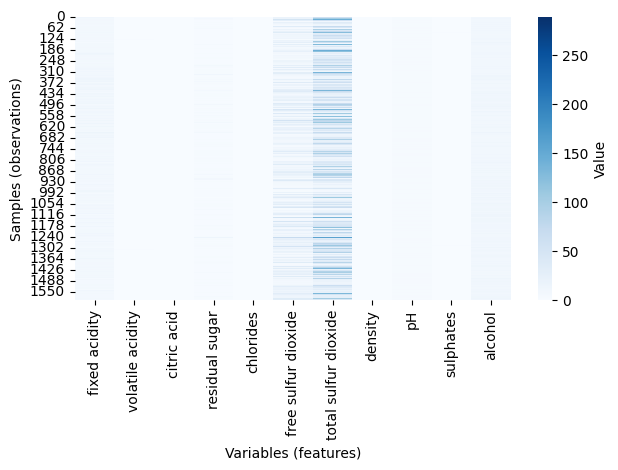

In [8]:
plt.figure()
sns.heatmap(X, cmap="Blues", cbar_kws={'label': 'Value'})
plt.xlabel("Variables (features)")
plt.ylabel("Samples (observations)")

# TODO needs scaling otherwise useless because total sulfur dominates
plt.tight_layout()
plt.show()

### 3.6 Pairplot

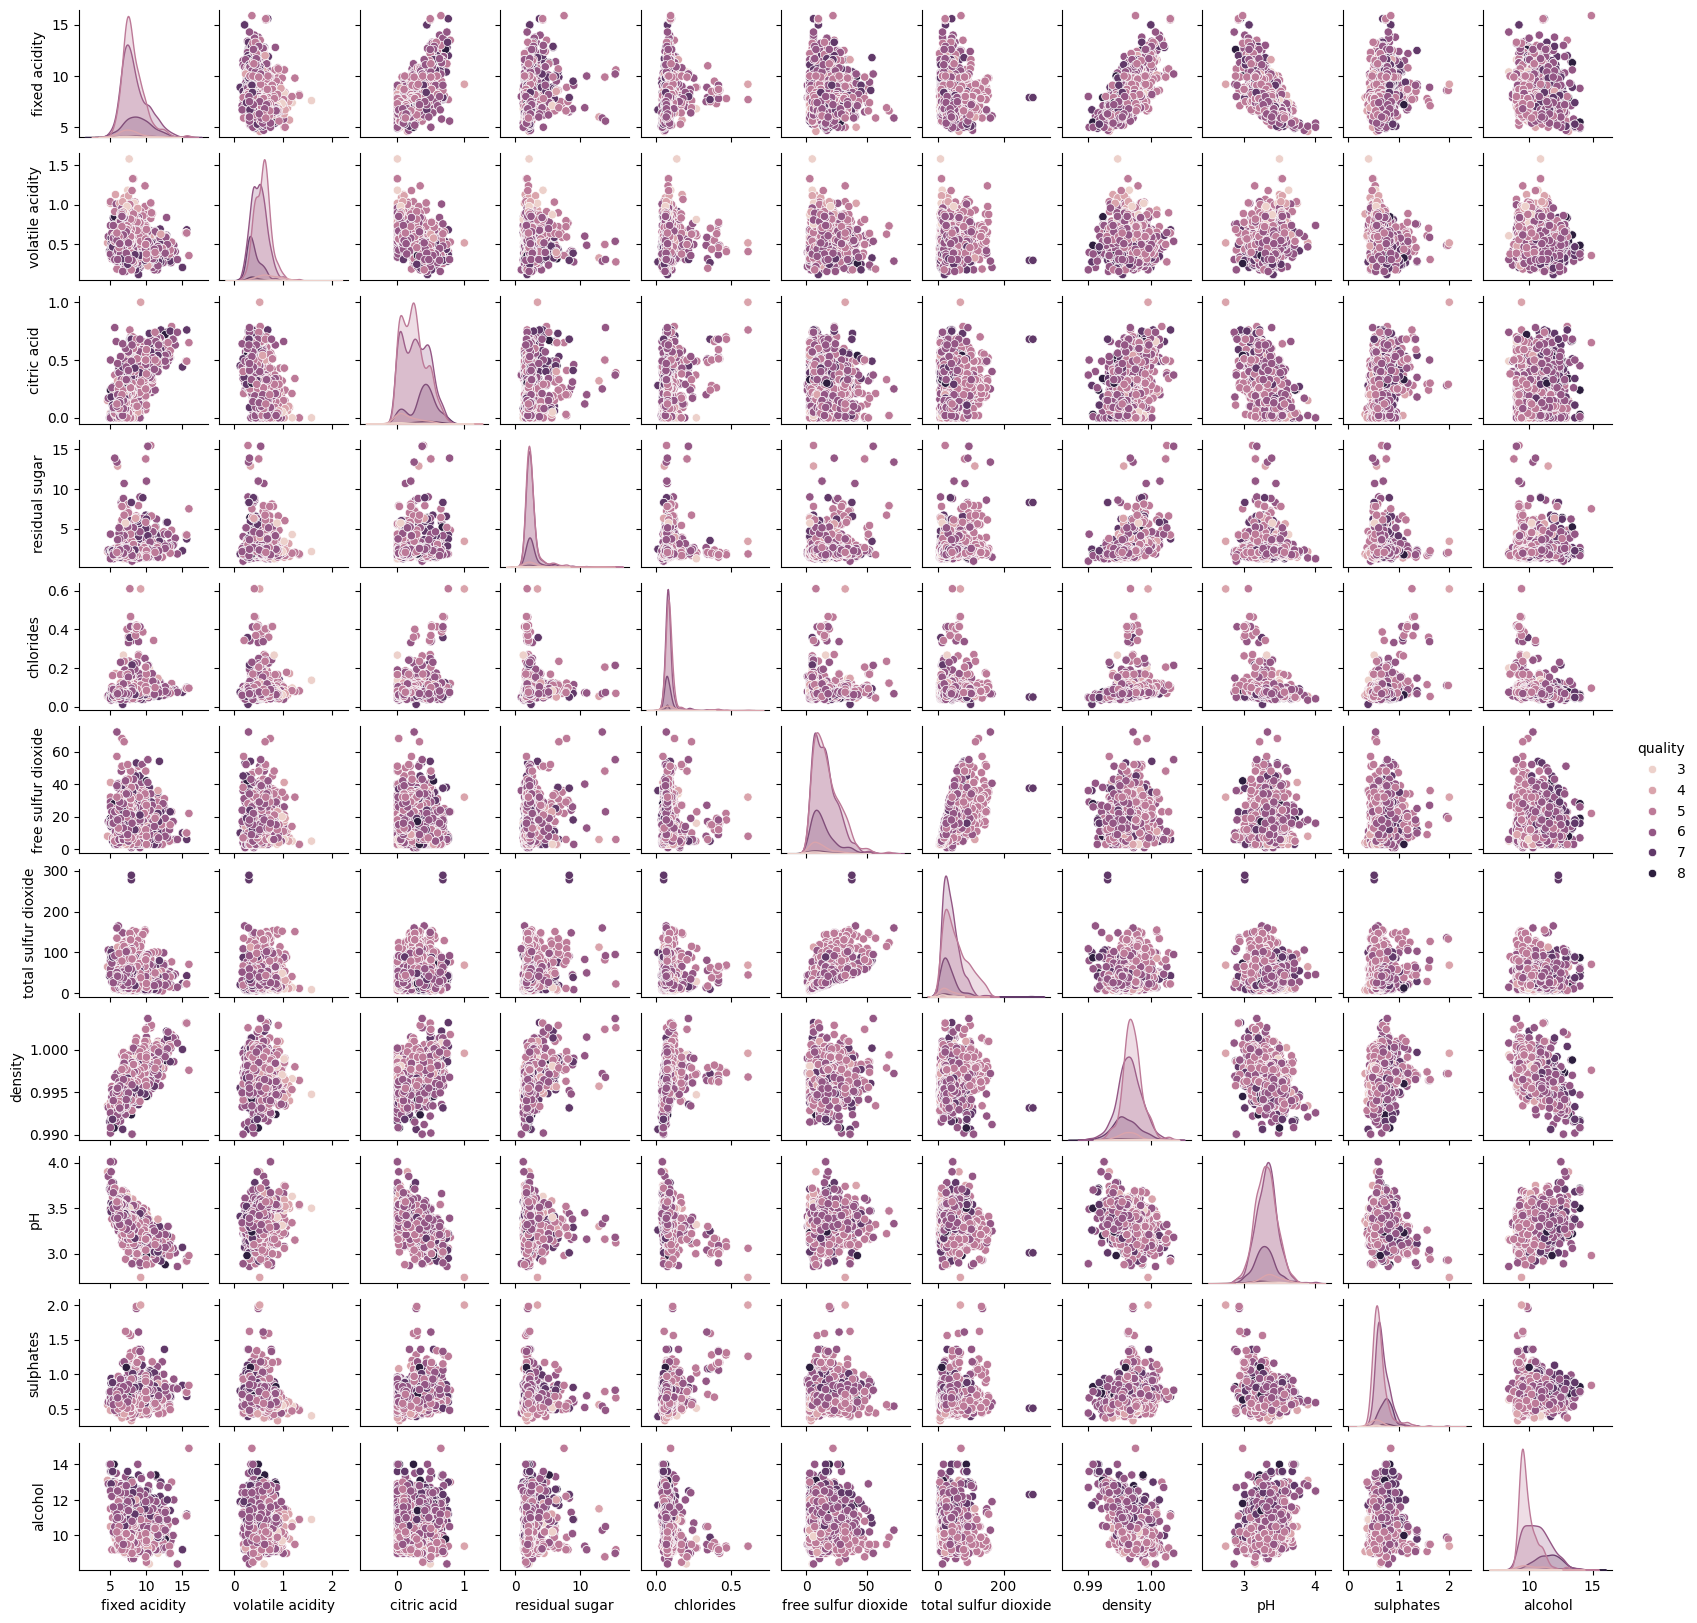

In [9]:
sns.pairplot(wine, hue='quality', height=1.5, aspect=1.0)

### Observations:
- Many features are intercorrelated
### Quality relationships:
- Alcohol: Higher quality wines (darker purple) tend toward higher alcohol

### 3.7 Correlation Matrix

<Figure size 640x480 with 0 Axes>

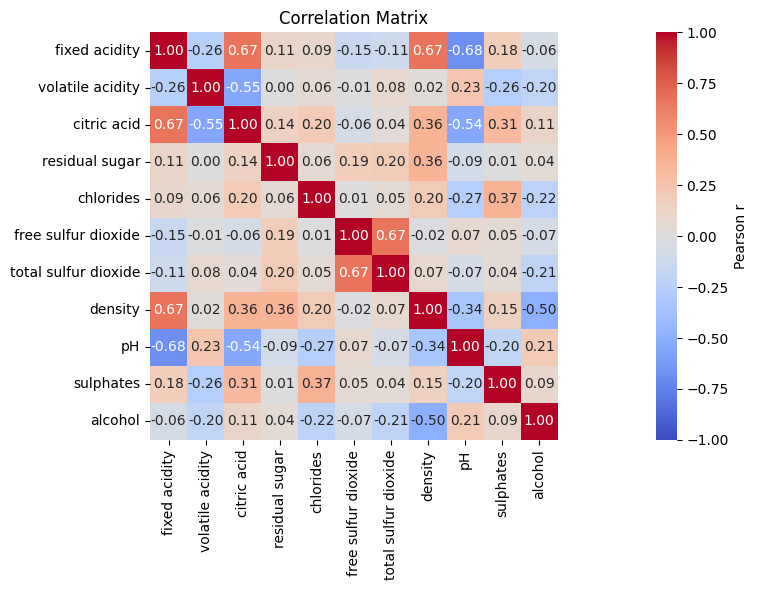

In [10]:
corr = X.corr()

plt.figure()
plt.figure(figsize=(20, 6))
sns.heatmap(
    corr,
    vmin=-1, vmax=1,
    cmap="coolwarm",
    annot=True,        # show correlation values
    fmt=".2f",         # format to 2 decimals
    square=True,       # make cells square
    cbar_kws={"label": "Pearson r"}
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 3.8 Correlation Matrix with correlation to quality

<Figure size 640x480 with 0 Axes>

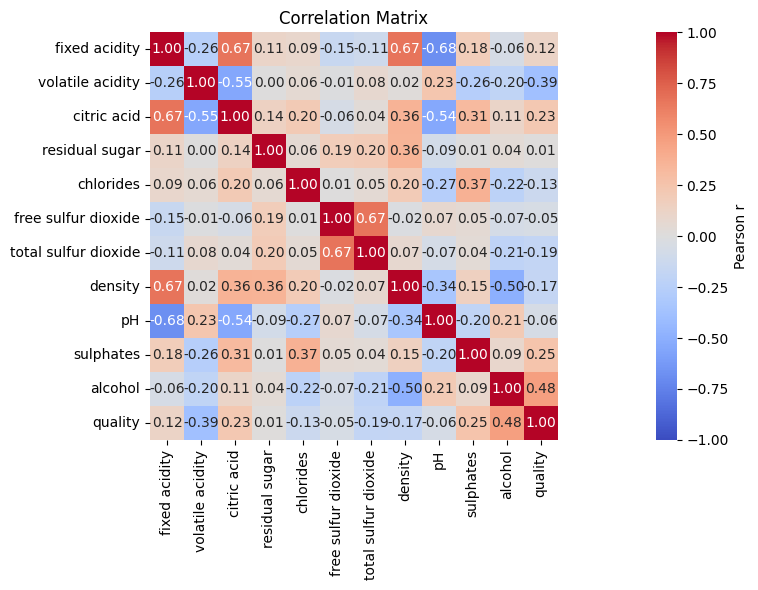

In [11]:
corr = wine.corr()

plt.figure()
plt.figure(figsize=(20, 6))
sns.heatmap(
    corr,
    vmin=-1, vmax=1,
    cmap="coolwarm",
    annot=True,        # show correlation values
    fmt=".2f",         # format to 2 decimals
    square=True,       # make cells square
    cbar_kws={"label": "Pearson r"}
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 3.9 Feature Selection

Selection of redundant features

Features with high correlation:
- fixed acidity & citric acidity  (0.67)
- fixed acidity & density (0.67)
- fixed acidity & ph (-0.68)
- Free sulfur dioxide & Total sulfur dioxide (0.67)

Features with low correlation to quality:
- fixed acidity 0.12
- free sulfur dioxide 0.05
- ph 0.06

Deshalb drop:
- 'fixed acidity', 'free sulfur dioxide', 'pH'


### Dropping Features with high correlation and low correlation to quality

In [12]:
target = 'quality'

# Korrelation aller Features mit der Zielvariable
correlations = wine.corr()[target].sort_values(ascending=False)
print(correlations)

X = X.drop(['fixed acidity', 'free sulfur dioxide', 'pH'], axis=1)

N_INPUT_FEATURES = 8
N_OUTPUT = 1

display(X.head())

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,sulphates,alcohol
0,0.70,0.00,1.9,0.076,34.0,0.9978,0.56,9.4
1,0.88,0.00,2.6,0.098,67.0,0.9968,0.68,9.8
2,0.76,0.04,2.3,0.092,54.0,0.9970,0.65,9.8
3,0.28,0.56,1.9,0.075,60.0,0.9980,0.58,9.8
4,0.70,0.00,1.9,0.076,34.0,0.9978,0.56,9.4


### 3.10 Scaling and Transformation

### Unsupervised Analysis: K-Means Clustering

To explore the structure of the data without using the target variable (*wine quality*), we apply **K-Means clustering** to the standardized features.

In this notebook:
- The data is first **standardized** using `StandardScaler` to ensure all features contribute equally.  
- We then initialized K-Means with **4 clusters (`n_clusters=4`)**, then with **3 clusters (`n_clusters=3`) ** and assigned each sample to one of these clusters.  
- The resulting cluster labels were added as a new column to the scaled dataset (`df_scaled["cluster"]`).

Finally, we visualized the clustering results using **Seaborn’s `pairplot`**, which plots each pair of features and colors the samples according to their assigned cluster.  
This helps identify whether there are **natural groupings or patterns** in the wine dataset — for instance, wines with similar chemical properties that might share similar quality characteristics.

---



variable means: 
volatile_acidity        1.733031e-16
citric_acid            -8.887339e-17
residual_sugar         -1.244227e-16
chlorides               3.732682e-16
total_sulfur_dioxide    4.443669e-17
density                -3.473172e-14
sulphates               6.754377e-16
alcohol                 1.066481e-16
dtype: float64)


<Figure size 640x480 with 0 Axes>

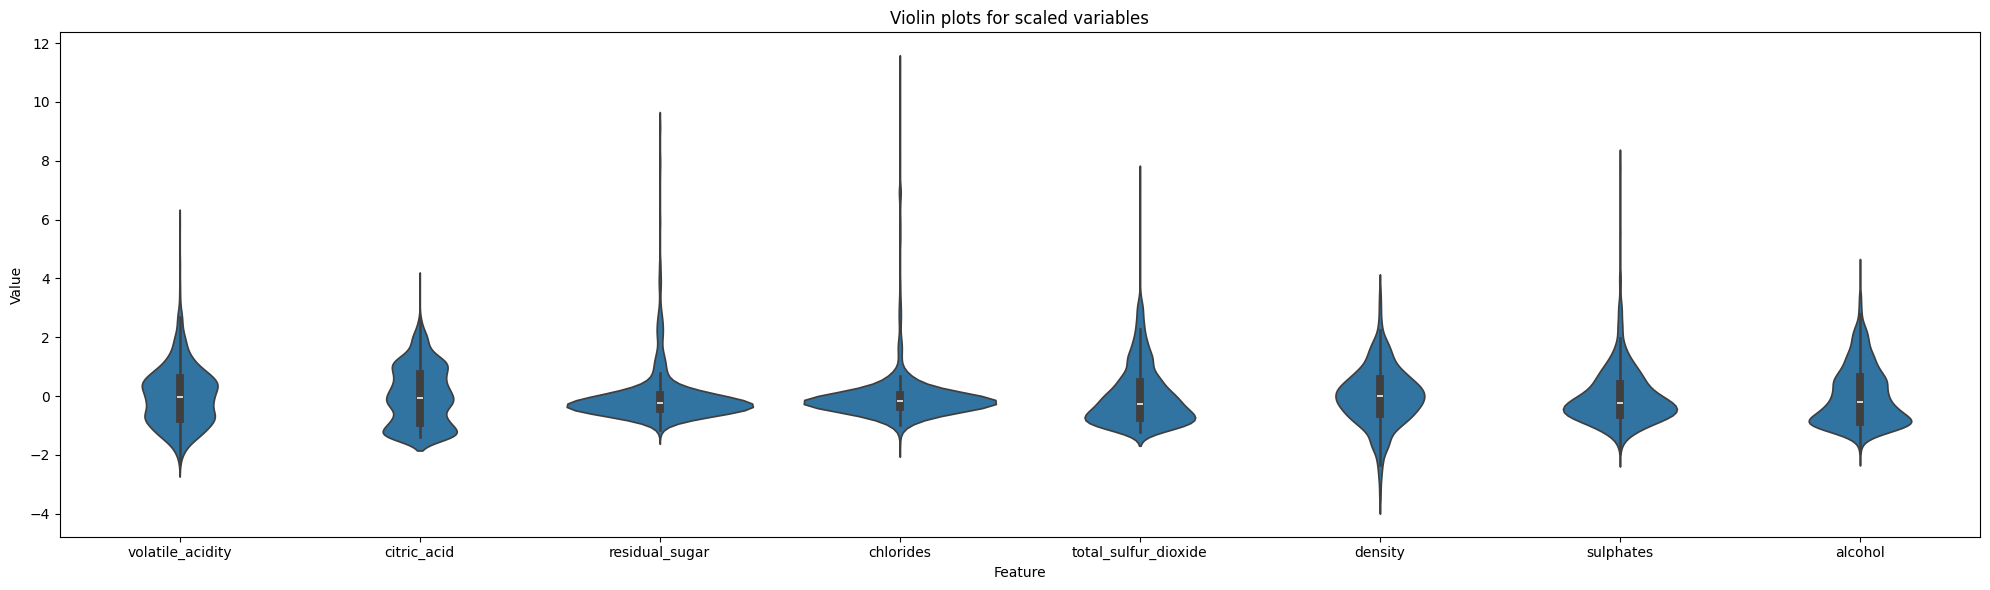

In [13]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# numpy2pandas (mostly for plotting convenience)

col_names = ["volatile_acidity", "citric_acid", "residual_sugar", "chlorides", "total_sulfur_dioxide", "density", "sulphates", "alcohol"]
df_scaled = pd.DataFrame(Xs, columns=col_names)
df_scaled_long = df_scaled.melt(var_name="Feature", value_name="Value")

print(f"variable means: \n{df_scaled.mean()})")
plt.figure()
plt.figure(figsize=(20, 6))
sns.violinplot(x="Feature", y="Value", data=df_scaled_long)
plt.title("Violin plots for scaled variables")
plt.tight_layout()
plt.show()

- Values are clusterd around +-2 Standard Units  

### 3.11 KMeans Clustering n=4

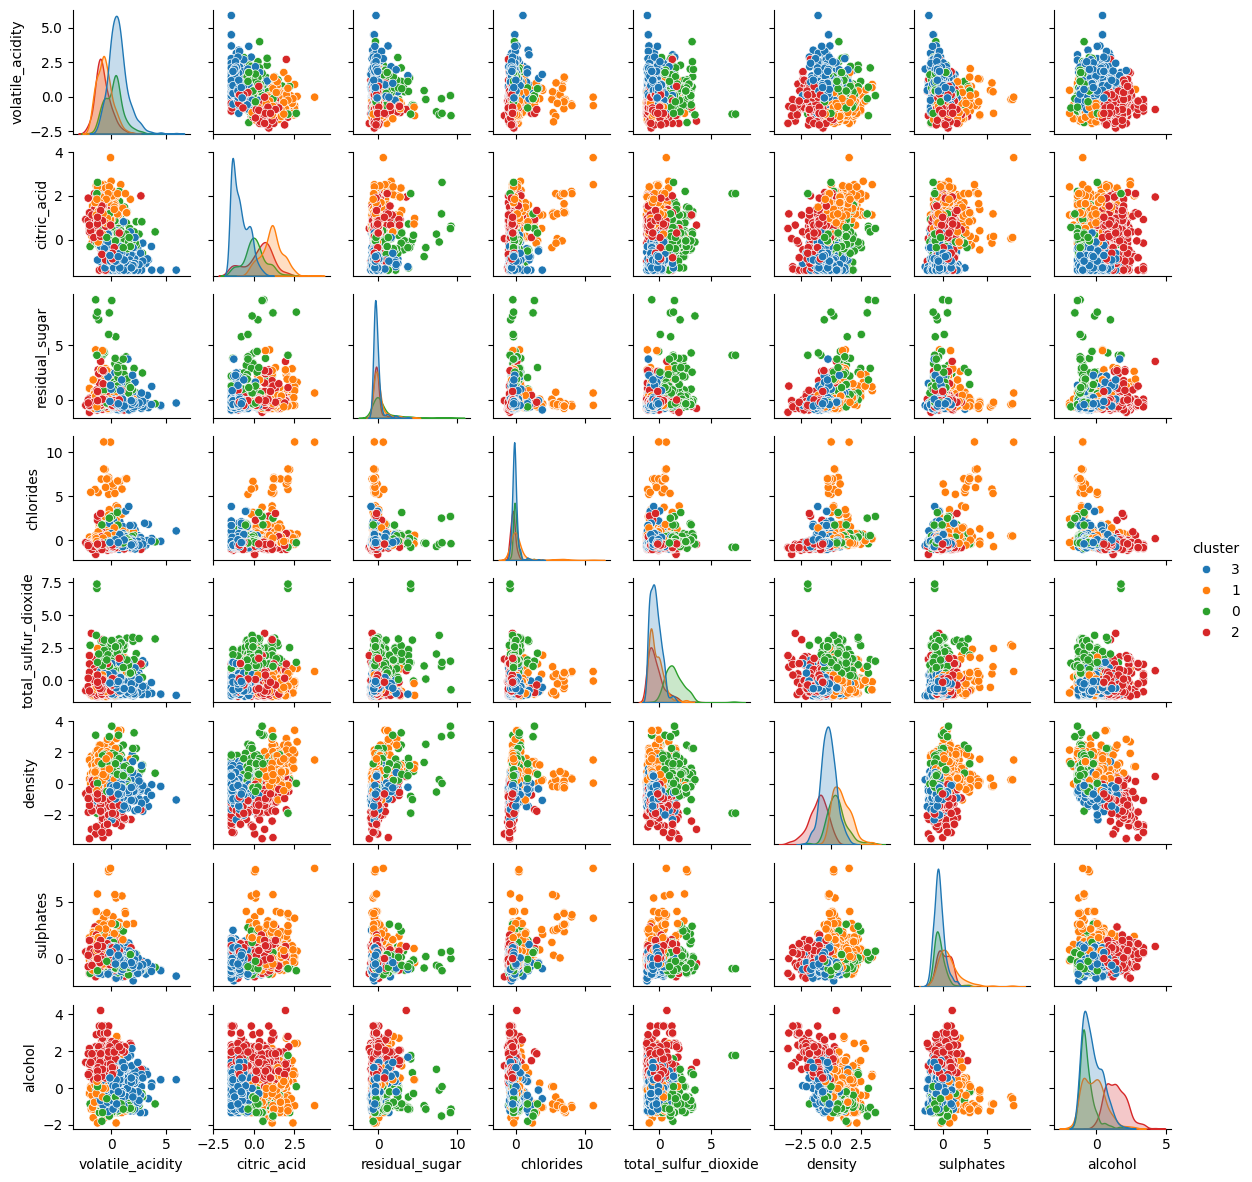

In [14]:

kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(Xs)

df_scaled["cluster"] = labels.astype(str)
sns.pairplot(df_scaled, hue="cluster", height=1.5, aspect=1.0)

### Observation:
- Most Values are clustered together but there are a few Outliers for every feature

### 3.12 KMeans Clustering n=3

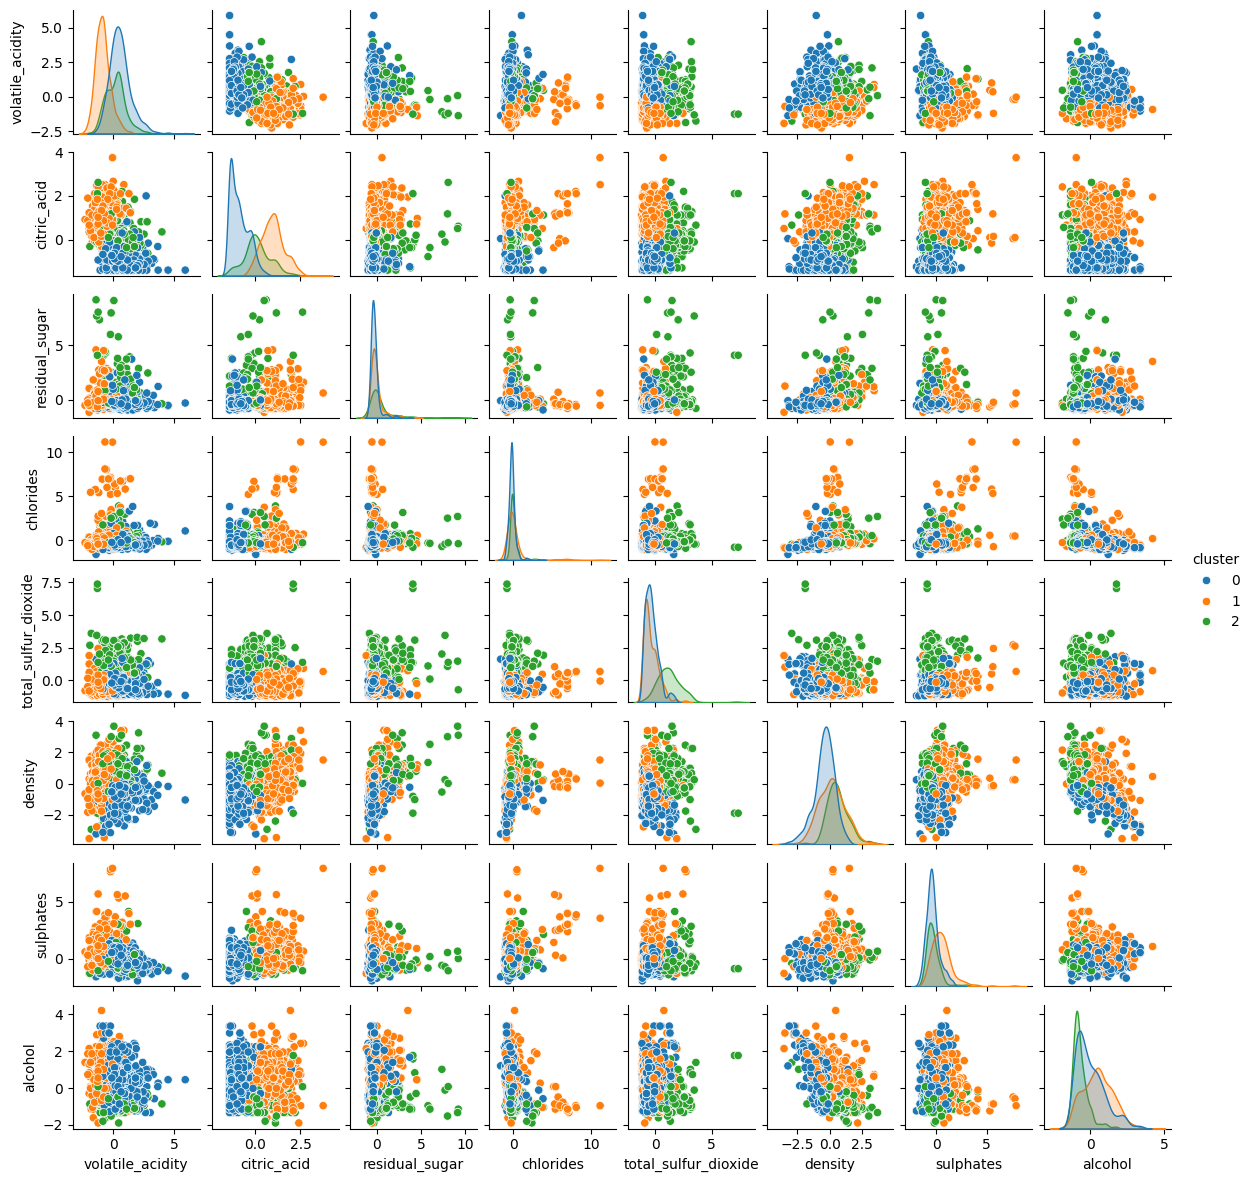

In [15]:
kmeans3 = KMeans(n_clusters=3)
labels = kmeans3.fit_predict(Xs)

df_scaled["cluster"] = labels.astype(str)
sns.pairplot(df_scaled, hue="cluster", height=1.5, aspect=1.0)

### 3.13 PCA Plot
### Unsupervised Analysis: Principal Component Analysis (PCA)

To further explore the internal structure of the dataset and visualize relationships between samples, we applied **PCA with two components (`n_components=2`)** to the standardized features, reducing the dataset from multiple chemical features to two principal axes.  
Finally, we plotted the samples on the **first two principal components (PC1 and PC2)** using a scatter plot.  

---


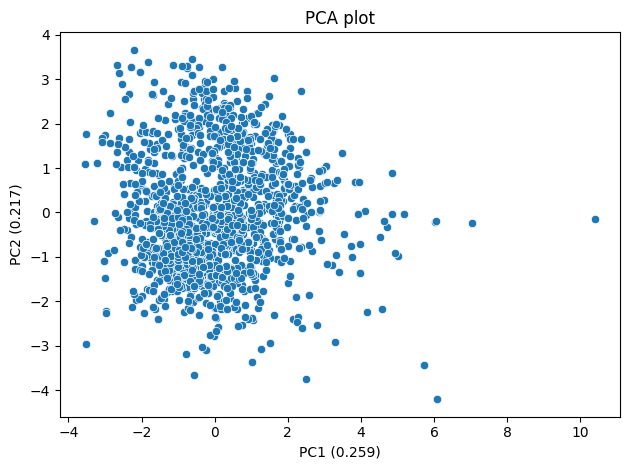

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xs)
var_exp = pca.explained_variance_ratio_

xlab = f"PC1 ({var_exp[0]:.3f})"
ylab = f"PC2 ({var_exp[1]:.3f})"
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])
plt.title("PCA plot")
plt.xlabel(xlab)
plt.ylabel(ylab)
plt.tight_layout()
plt.show()

**Variance distribution:**
- PC1 explains 25.9% of variance
- PC2 explains 21.7% of variance  
- Together only ~48% - relatively low

**Structure:**
- No clear clusters visible - wines form a largely continuous cloud
- Some outliers at the edges (especially right and bottom)
- No obvious separation by quality classes

# 4. Baseline Model Definition

**Baseline Model Choice:**  Supervised Linear Regression Model $x\to y$
- Architecture: Single linear layer (8 inputs -> 1 output)
  - 8 Features as Quality Indicators
  - 1 Target Variable (Wine Quality)
  - There are 1279 Samples left after filtering
  - And 3 Features have been dropped and the Target excluded
- Loss function: MSE (Mean Squared Error)
- Optimizer: SGD with learning rate 0.001
  - Stochastic: Uses random batches instead of entire dataset
  - Gradients: are computed (how much each parameter affects loss)
  - Decent: with fixed learning rate
- Why these choices:
  - Linear model: baseline before trying complex architectures
  - Why SGD? in this particular case faster convergence than Adam
  - LR=0.001: standard starting point [*2]
    - tested 0.01 as well, but worse performance

### 4.1 Model Architecture and Loss Function

In [17]:
LEARNING_RATE = 0.001


model = nn.Sequential(nn.Linear(N_INPUT_FEATURES, N_OUTPUT))
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


### 5.1 Train/Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y.values, test_size=0.2, random_state=42
)

x_t = torch.as_tensor(X_train, dtype=torch.float32)
y_t = torch.as_tensor(y_train, dtype=torch.float32).view(-1, 1)
x_test_t = torch.as_tensor(X_test, dtype=torch.float32)
y_test_t = torch.as_tensor(y_test, dtype=torch.float32).view(-1, 1)

print(f"shape(x_t): {x_t.shape}")
print(f"shape(y_t): {y_t.shape}")


shape(x_t): torch.Size([1279, 8])
shape(y_t): torch.Size([1279, 1])


The dataset was split into two parts: a training set (80 %) and a test set (20%). This was done to stop the model from learning a specific pattern in the data and then using that same pattern with new or unseen data. This could cause some overfitting. The 80/20 split provides enough data for the model to learn effectively (80%) while keeping enough unseen data (20%) to test generalization performance fairly and reliably.






### 5.2 Training Loop

In [19]:
losses = []
model.train()
for epoch in range(3000):
    y_pred = model(x_t) # forward pass: compute predictions
    loss = loss_func(y_pred, y_t) # calculate loss
    loss.backward() # backward pass: compute gradients
    optimizer.step() # update parameters using gradients
    optimizer.zero_grad() # reset gradients to zero

    losses.append(loss.item()) # keep track of losses

# finished training. inspect model
print('Mean Squared Error (loss):    ',loss.item())
print('Parameters:')
for name, p in model.named_parameters():
    print(name, p.detach())

Mean Squared Error (loss):     0.4309908151626587
Parameters:
0.weight tensor([[-0.1571,  0.0563,  0.0186, -0.0892, -0.0939, -0.0332,  0.1462,  0.2698]])
0.bias tensor([5.6136])


### Learned Weights:
- how much the features affect the endresult

### Learnd Bias:
- 0.bias tensor([5.5227])
- shifts the activation function left/right (or up/down)

### Formular

- **output = weights × inputs + bias**

### 5.3 Loss History

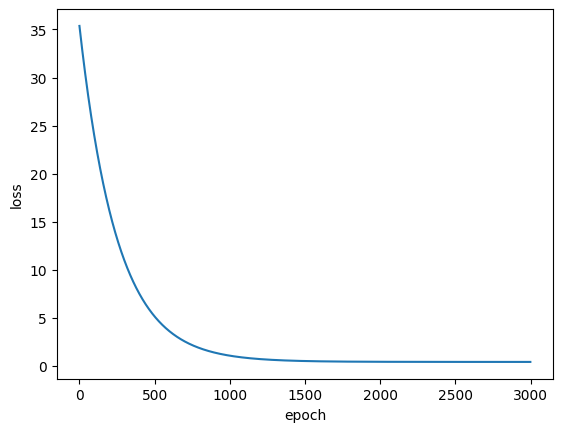

In [20]:
plt.figure()
plt.plot(losses)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

### Analysis of Loss History:
- Shows dropof of progress at 1500-2000

# 6. Evaluate Baseline Model

### 6.0 Check effect of dropped features
- needs furter analysis
- but in removing the featurs no significant drop in the model perfomance was noticed except for ph but it was still mariginal



### 6.1 Test Set Evaluation

>  Is the model overfitting?

- MSE = 0.4434940814971924 on baseline model for 2000 epochs
- MSE = 0.43090954422950745 on baseline model for 3000 epochs
- MSE = 0.4302169978618622 on baseline model for 3000 epochs
- Test MSE: 0.4194 value on test data for 2000 epochs
- Test MSE: 0.3976 after for 3000 epochs
- Test MSE: 0.3954 after for 3000 epochs

***Gains Marginal Early Stopping at 3k epochs!***

Test MSE: 0.3978
Test RMSE: 0.6307
Test MAE: 0.5074
R² score: 0.391


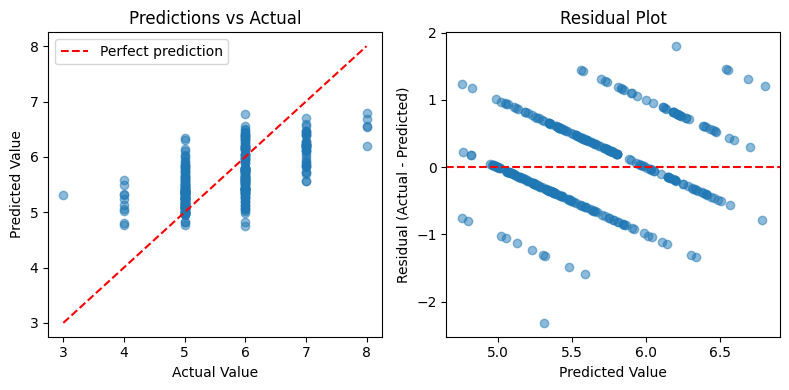

In [21]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_t)
    test_loss = loss_func(y_pred_test, y_test_t)

#Printing metrics calculated for the model
print(f'Test MSE: {test_loss.item():.4f}')
rmse = np.sqrt(mean_squared_error(y_test_t.numpy(), y_pred_test.numpy()))
mae = mean_absolute_error(y_test_t.numpy(), y_pred_test.numpy())
r2 = r2_score(y_test_t.numpy(), y_pred_test.numpy())

print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE: {mae:.4f}')
print(f'R² score: {r2:.3f}')


# Plot predictions vs actual
plt.figure(figsize=(8, 4))

# Subplot 1: Predicted vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test_t, y_pred_test.detach(), alpha=0.5)
plt.plot([y_test_t.min(), y_test_t.max()], [y_test_t.min(), y_test_t.max()], 'r--', label='Perfect prediction')  # diagonal line
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Predictions vs Actual')
plt.legend()

# Subplot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test_t - y_pred_test.detach()
plt.scatter(y_pred_test.detach(), residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

### 6.2 Why Use Separate Test Set?
The test set provides an unbiased evaluation of model performance on unseen data.

Without it, we'd evaluate on the same data used for training, overestimating accuracy and missing overfitting issues.

This simulates real-world deployment where the model encounters new samples


# 7. Improve Model

## 7.1 Improved Model Architecture

Architecture:
- Input: 8 features
- Hidden layer: 16 neurons with ReLU activation
- Output: 1 neuron (predicting wine quality)


In [22]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define improved model
class ImprovedModel(nn.Module):
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.hidden = nn.Linear(n_input, n_hidden)
        self.relu = nn.ReLU()
        self.output = nn.Linear(n_hidden, n_output)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Instantiate model, loss, optimizer
improved_model = ImprovedModel(n_input=8, n_hidden=16, n_output=1)
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(improved_model.parameters(), lr=0.001)




### 7.2 Train Improved Model

Final Training MSE: 0.3801


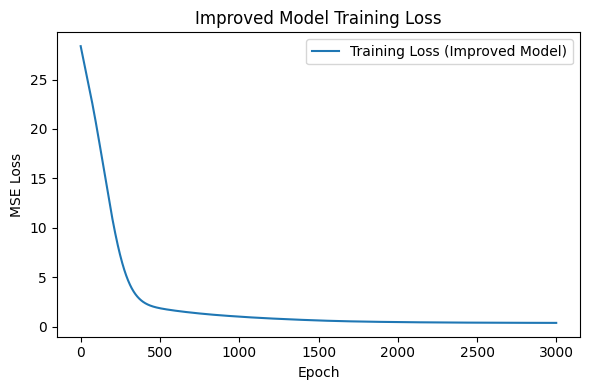

In [23]:
# Training loop
epochs = 3000
train_losses = []

improved_model.train()
for epoch in range(epochs):
    y_pred = improved_model(x_t)
    loss = loss_func(y_pred, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

print(f"Final Training MSE: {train_losses[-1]:.4f}")

# Plot training loss curve
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Training Loss (Improved Model)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Improved Model Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Evaluate Improved Model

In [24]:
improved_model.eval()
with torch.no_grad():
    y_pred_test_nn = improved_model(x_test_t)
    test_loss_nn = loss_func(y_pred_test_nn, y_test_t)

# Compute evaluation metrics
rmse_nn = np.sqrt(mean_squared_error(y_test_t.numpy(), y_pred_test_nn.numpy()))
mae_nn = mean_absolute_error(y_test_t.numpy(), y_pred_test_nn.numpy())
r2_nn = r2_score(y_test_t.numpy(), y_pred_test_nn.numpy())

print(f"Improved Model Test MSE: {test_loss_nn.item():.4f}")
print(f"Improved Model RMSE: {rmse_nn:.4f}")
print(f"Improved Model MAE: {mae_nn:.4f}")
print(f"Improved Model R² score: {r2_nn:.3f}")

Improved Model Test MSE: 0.3947
Improved Model RMSE: 0.6283
Improved Model MAE: 0.4966
Improved Model R² score: 0.396


### 7.4 Baseline vs Improved Comparison
Baseline Linear Model
- Test MSE: 0.3976
- R² score: 0.392


 Improved Neural Model
- Test MSE: 0.3947
- R² score: 0.396

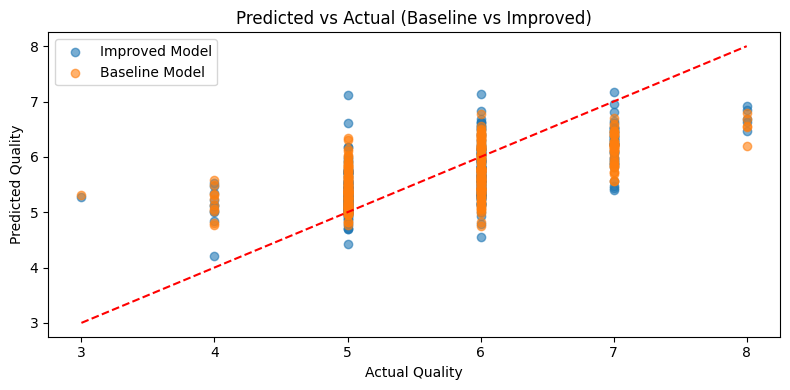

In [25]:
plt.figure(figsize=(8,4))
plt.scatter(y_test_t, y_pred_test_nn, alpha=0.6, label='Improved Model')
plt.scatter(y_test_t, y_pred_test.detach(), alpha=0.6, label='Baseline Model')
plt.plot([y_test_t.min(), y_test_t.max()], [y_test_t.min(), y_test_t.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Predicted vs Actual (Baseline vs Improved)')
plt.legend()
plt.tight_layout()
plt.show()

# 8. Summary and Critical Reflection

### Summary of Steps
1. **Setup and Environment:**  
   Verified consistent versions of key libraries (NumPy, Pandas, Scikit-learn, PyTorch) for a reproducible setup.
2. **Data Loading and Exploration:**  
   Loaded the Red Wine Quality dataset from the UCI Repository and analyzed distributions, feature correlations, and missing values.
3. **Data Preparation:**  
   Removed redundant and highly correlated variables, normalized all continuous features using `StandardScaler`.
4. **Unsupervised Analysis:**  
   Applied K-Means clustering and PCA to identify potential natural groupings and reduce dimensionality for exploratory visualization.
5. **Model Definition:**  
   Implemented a baseline **linear regression model** (PyTorch) as a reference for predictive performance.
6. **Training and Evaluation (Baseline):**  
   Trained the linear model for 3000 epochs using MSE loss and SGD optimizer, evaluated performance using MSE, RMSE, MAE, and R² metrics.
7. **Model Improvement (Neural Network):**  
   Introduced a nonlinear model with one hidden layer (8–16–1 architecture) and ReLU activation, trained with the Adam optimizer (learning rate 0.001).  

---

### Results
- The **baseline linear model** performed reasonably but could not capture nonlinear dependencies between chemical properties and wine quality.  
- The **improved neural network** achieved a slightly **lower MSE** and **higher R² score**
-  The changes are small, but significant. Still,  this does not fully require the use a more complex model.
- Both models demonstrated consistent results with proper feature scaling and an 80/20 train-test split.

> The **improved neural network** showed only slightly **lower MSE** and slightly **higher R² score**, suggesting the linear model was sufficient for this dataset or that the neural network requires more tuning (regularization, different architecture).

---

### Critical Reflection
**Assumptions:**  
Both models assume that the features are accurate predictors of wine quality and that there are no strong external confounders.  
The linear model assumes additive relationships, while the neural network relaxes this assumption but still depends on adequate feature scaling and data balance.

**Limitations:**  
- The dataset remains **unbalanced** across quality levels (most samples are of medium quality).  
- The dataset includes only **numerical chemical features**, omitting sensory or categorical information that could improve performance.  
- While the neural network performs better, it may **overfit** slightly due to limited sample diversity.

**Future Improvements:**  
- Extend the model with additional hidden layers, dropout, or batch normalization to further explore nonlinear dependencies.  
- Incorporate data augmentation or resampling strategies to balance quality levels.  
- Experiment with ensemble methods or tree-based regressors (e.g., Random Forests, Gradient Boosting) for comparison.